In [1]:
import pandas as pd
import numpy as np
import random
import torch

In [2]:
import ast

In [3]:
sensitive_boundaries_results_path = "/scratch1/smaruj/natural_boundaries/single_sensitive_boundary_results.tsv"
df = pd.read_csv(sensitive_boundaries_results_path, sep="\t")

In [4]:
df

,SCD_h1_m0_t0,SCD_h1_m0_t1,SCD_h1_m0_t2,SCD_h1_m0_t3,SCD_h1_m0_t4,SCD_h1_m0_t5,chrom,end,rel_disruption_end,rel_disruption_start,start,type,window_end,window_start,disrupted_bin,SCD,URQ_mean_og,URQ_mean_perm
0,12.625,13.98,9.84,9.760,10.56,8.800,chr1,4410000,667648,665600,4400000,up4,5061504,3750784,261,14.219098,-0.425214,-0.402955
1,39.750,45.53,46.88,47.340,45.80,40.400,chr1,4780000,649216,647168,4770000,down1,5431504,4120784,252,35.792278,-0.149015,-0.100953
2,18.620,21.22,15.00,14.470,16.05,13.266,chr1,5160000,684032,681984,5150000,up12,5811504,4500784,269,14.450966,-0.317068,-0.281380
3,38.250,49.34,53.12,48.970,49.88,41.120,chr1,5910000,655360,653312,5900000,tad3,6561504,5250784,255,34.648056,-0.249874,-0.164008
4,12.480,14.41,14.84,15.160,13.95,11.836,chr1,6200000,651264,649216,6190000,tad1,6851504,5540784,253,4.890842,-0.276848,-0.281949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4469,13.080,14.07,22.34,22.400,19.30,17.110,chr9,121460000,679936,677888,121450000,up10,122111504,120800784,267,24.533665,-0.109020,-0.081135
4470,9.890,9.09,10.04,10.080,9.66,8.310,chr9,121710000,647168,645120,121700000,down2,122361504,121050784,251,19.806274,-0.260271,-0.259473
4471,8.640,8.55,8.88,8.586,8.47,7.280,chr9,122360000,651264,649216,122350000,tad1,123011504,121700784,253,9.779501,-0.057232,-0.047916
4472,33.400,36.03,49.88,50.530,45.03,39.880,chr9,122730000,667648,665600,122720000,up4,123381504,122070784,261,40.874256,-0.176782,-0.147446


In [5]:
import matplotlib.pyplot as plt

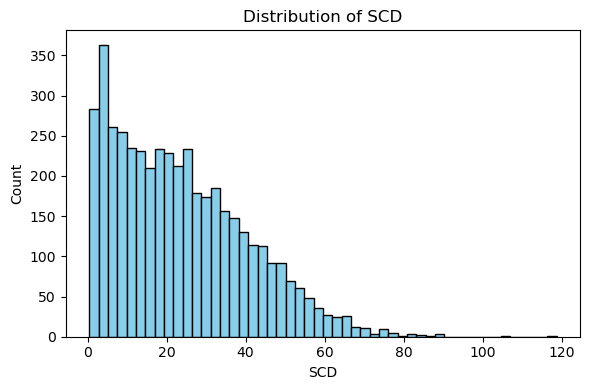

In [6]:
# Plot SCD histogram
plt.figure(figsize=(6, 4))
plt.hist(df["SCD"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of SCD")
plt.xlabel("SCD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

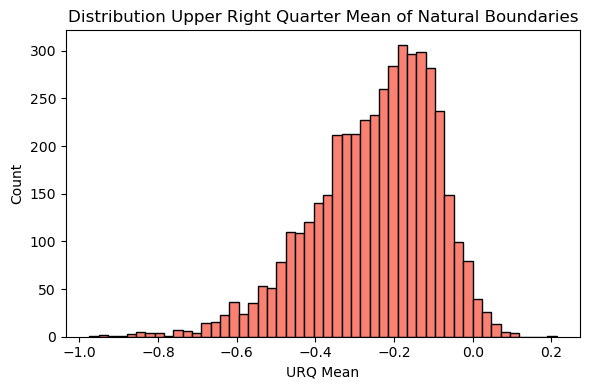

In [7]:
# Plot DeltaBoundaryStrength histogram
plt.figure(figsize=(6, 4))
plt.hist(df["URQ_mean_og"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution Upper Right Quarter Mean of Natural Boundaries")
plt.xlabel("URQ Mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
df["URQ_mean_og"].min(), df["URQ_mean_og"].mean()

(-0.9748536, -0.24901257995203624)

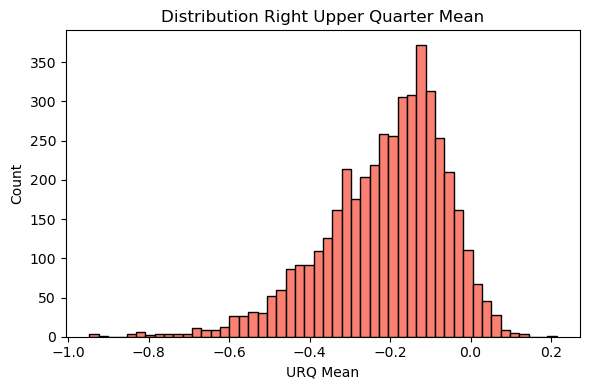

In [9]:
# Plot DeltaBoundaryStrength histogram
plt.figure(figsize=(6, 4))
plt.hist(df["URQ_mean_perm"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution Right Upper Quarter Mean")
plt.xlabel("URQ Mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/tmp/SLURM_1127400/ipykernel_1733506/473624609.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Before (URQ_mean_og)', 'After (URQ_mean_perm)'])


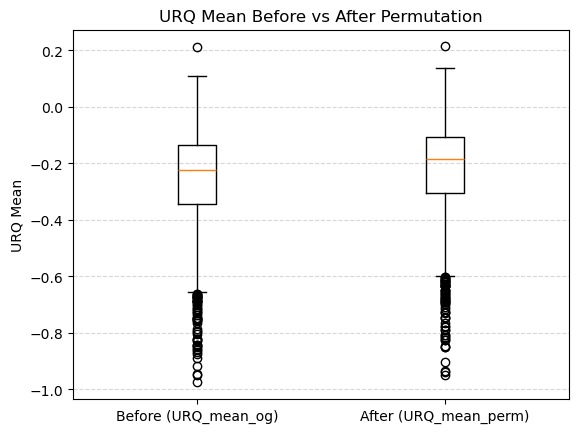

In [10]:
# Create the data in long format for boxplotting
data_to_plot = [df['URQ_mean_og'], df['URQ_mean_perm']]

# Make the boxplot
plt.boxplot(data_to_plot, labels=['Before (URQ_mean_og)', 'After (URQ_mean_perm)'])
plt.ylabel('URQ Mean')
plt.title('URQ Mean Before vs After Permutation')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## CTCFs analysis

In [11]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices, dtype=int)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [12]:
from pyfaidx import Fasta

In [13]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [14]:
def get_sequence(genome, chrom, start, bin_idx, cropping=64, bin_size=2048):
    bin_start = start + (bin_idx + cropping) * bin_size
    bin_end = bin_start + bin_size
    seq = genome[chrom][bin_start:bin_end].seq.upper()
    ohe_seq = one_hot_encode_sequence(seq)
    return np.expand_dims(ohe_seq, axis=0)

In [15]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [16]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [17]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [18]:
from tangermeme.tools import fimo

In [19]:
all_hits = []

for idx, row in df.iterrows():
    chrom = row["chrom"]
    window_start = row["window_start"]
    window_end = row["window_end"]
    scd = row["SCD"]
    og_URQ = row["URQ_mean_og"]
    perm_URQ = row["URQ_mean_perm"]
    bin_idx = row["disrupted_bin"]

    sequence = get_sequence(genome, chrom, window_start, bin_idx)

    hits = fimo.fimo(
        motifs=motifs_dict,
        sequences=sequence,
        threshold=1e-4,
        reverse_complement=True
    )[0]

    # Only add non-empty results
    if not hits.empty:
        hits = hits.assign(
            chrom=chrom,
            window_start=window_start,
            window_end=window_end,
            bin_idx=bin_idx,
            scd=scd,
            URQ_mean_og=og_URQ,
            URQ_mean_perm=perm_URQ,
            ctcf_count=len(hits)
        )
        all_hits.append(hits)
    else:
        # Add a single row with ctcf_count = 0
        empty_row = {
            "chrom": chrom,
            "window_start": window_start,
            "window_end": window_end,
            "bin_idx": bin_idx,
            "scd": scd,
            "URQ_mean_og": og_URQ,
            "URQ_mean_perm": perm_URQ,
            "ctcf_count": 0
        }
        all_hits.append(pd.DataFrame([empty_row]))

In [20]:
combined_hits_df = pd.concat(all_hits, ignore_index=True)

In [21]:
combined_hits_df

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value,chrom,window_start,window_end,bin_idx,scd,URQ_mean_og,URQ_mean_perm,ctcf_count
0,CTCF,0.0,0.0,515.0,534.0,-,18.380678,4.184731e-07,chr1,3750784,5061504,261,14.219098,-0.425214,-0.402955,1
1,CTCF,0.0,0.0,590.0,609.0,-,19.636239,1.538319e-07,chr1,4120784,5431504,252,35.792278,-0.149015,-0.100953,1
2,CTCF,0.0,0.0,912.0,931.0,+,14.961813,3.860347e-06,chr1,4500784,5811504,269,14.450966,-0.317068,-0.281380,2
3,CTCF,0.0,0.0,1757.0,1776.0,-,10.889385,3.357631e-05,chr1,4500784,5811504,269,14.450966,-0.317068,-0.281380,2
4,CTCF,0.0,0.0,1314.0,1333.0,+,8.493650,9.886088e-05,chr1,5250784,6561504,255,34.648056,-0.249874,-0.164008,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6900,CTCF,0.0,0.0,1886.0,1905.0,-,12.602928,1.373836e-05,chr9,121700784,123011504,253,9.779501,-0.057232,-0.047916,3
6901,CTCF,0.0,0.0,538.0,557.0,+,23.762212,2.044544e-09,chr9,122070784,123381504,261,40.874256,-0.176782,-0.147446,1
6902,CTCF,0.0,0.0,1988.0,2007.0,+,10.158748,4.658175e-05,chr9,122480784,123791504,266,22.192314,-0.146953,-0.106414,3
6903,CTCF,0.0,0.0,921.0,940.0,-,12.583158,1.446826e-05,chr9,122480784,123791504,266,22.192314,-0.146953,-0.106414,3


In [22]:
grouped_df = combined_hits_df.groupby(
    ["chrom", "window_start", "window_end", "scd", "URQ_mean_og", "URQ_mean_perm"], as_index=False
).agg(
    score_max=("score", "max"),
    score_sum=("score", "sum"),
    motif_count=("score", "count"),
    strand_concat=("strand", lambda x: ",".join(x.astype(str)))
)

In [23]:
grouped_df

,chrom,window_start,window_end,scd,URQ_mean_og,URQ_mean_perm,score_max,score_sum,motif_count,strand_concat
0,chr1,3750784,5061504,14.219098,-0.425214,-0.402955,18.380678,18.380678,1,-
1,chr1,4120784,5431504,35.792278,-0.149015,-0.100953,19.636239,19.636239,1,-
2,chr1,4500784,5811504,14.450966,-0.317068,-0.281380,14.961813,25.851198,2,"+,-"
3,chr1,5250784,6561504,34.648056,-0.249874,-0.164008,14.629683,23.123333,2,"+,-"
4,chr1,5540784,6851504,4.890842,-0.276848,-0.281949,12.621321,24.569232,2,"-,-"
...,...,...,...,...,...,...,...,...,...,...
4469,chr9,120800784,122111504,24.533665,-0.109020,-0.081135,16.210295,26.423888,2,"+,+"
4470,chr9,121050784,122361504,19.806274,-0.260271,-0.259473,25.082540,177.738743,8,"+,+,+,+,+,+,+,-"
4471,chr9,121700784,123011504,9.779501,-0.057232,-0.047916,12.602928,35.420018,3,"+,+,-"
4472,chr9,122070784,123381504,40.874256,-0.176782,-0.147446,23.762212,23.762212,1,+


In [24]:
grouped_df["motif_count"].mean(), grouped_df["motif_count"].min(), grouped_df["motif_count"].max()

(1.429816718819848, 0, 16)

In [25]:
all_edited_hits = []

for idx, row in df.iterrows():
    chrom = row["chrom"]
    window_start = row["window_start"]
    window_end = row["window_end"]
    scd = row["SCD"]
    og_URQ = row["URQ_mean_og"]
    perm_URQ = row["URQ_mean_perm"]
    bin_idx = row["disrupted_bin"]

    # Load permuted .npy file (assumes precomputed)
    filename = f"/scratch1/smaruj/natural_boundaries/permuted_bins/{chrom}_{window_start}-{window_end}.npy"
    
    one_hot = np.load(filename)  # Already (4, bin_size)
    one_hot = np.expand_dims(one_hot, axis=0)
    
    hits = fimo.fimo(
        motifs=motifs_dict,
        sequences=one_hot,
        threshold=1e-4,
        reverse_complement=True
    )[0]

    # Only add non-empty results
    if not hits.empty:
        hits = hits.assign(
            chrom=chrom,
            window_start=window_start,
            window_end=window_end,
            bin_idx=bin_idx,
            scd=scd,
            URQ_mean_og=og_URQ,
            URQ_mean_perm=perm_URQ,
            ctcf_count=len(hits)
        )
        all_edited_hits.append(hits)
    else:
        # Add one row with ctcf_count = 0
        empty_row = {
            "chrom": chrom,
            "window_start": window_start,
            "window_end": window_end,
            "bin_idx": bin_idx,
            "scd": scd,
            "URQ_mean_og": og_URQ,
            "URQ_mean_perm": perm_URQ,
            "ctcf_count": 0
        }
        all_edited_hits.append(pd.DataFrame([empty_row]))

In [26]:
combined_edited_hits_df = pd.concat(all_edited_hits, ignore_index=True)

In [28]:
grouped_edited_df = combined_edited_hits_df.groupby(
    ["chrom", "window_start", "window_end", "scd", "URQ_mean_og", "URQ_mean_perm"], as_index=False
).agg(
    score_max=("score", "max"),
    score_sum=("score", "sum"),
    motif_count=("score", "count"),
    strand_concat=("strand", lambda x: ",".join(x.astype(str)))
)

In [29]:
grouped_edited_df

,chrom,window_start,window_end,scd,URQ_mean_og,URQ_mean_perm,score_max,score_sum,motif_count,strand_concat
0,chr1,3750784,5061504,14.219098,-0.425214,-0.402955,9.751651,9.751651,1,-
1,chr1,4120784,5431504,35.792278,-0.149015,-0.100953,NaN,0.000000,0,nan
2,chr1,4500784,5811504,14.450966,-0.317068,-0.281380,NaN,0.000000,0,nan
3,chr1,5250784,6561504,34.648056,-0.249874,-0.164008,NaN,0.000000,0,nan
4,chr1,5540784,6851504,4.890842,-0.276848,-0.281949,NaN,0.000000,0,nan
...,...,...,...,...,...,...,...,...,...,...
4469,chr9,120800784,122111504,24.533665,-0.109020,-0.081135,NaN,0.000000,0,nan
4470,chr9,121050784,122361504,19.806274,-0.260271,-0.259473,NaN,0.000000,0,nan
4471,chr9,121700784,123011504,9.779501,-0.057232,-0.047916,NaN,0.000000,0,nan
4472,chr9,122070784,123381504,40.874256,-0.176782,-0.147446,NaN,0.000000,0,nan


In [30]:
grouped_edited_df["motif_count"].mean()

0.23446580241394724

In [31]:
# Merge on chrom, window_start, window_end
merged_df = grouped_df.merge(
    grouped_edited_df,
    on=["chrom", "window_start", "window_end"],
    suffixes=("_original", "_shuffled")
)

# Compute CTCF difference
merged_df["ctcf_count_diff"] = (
    merged_df["motif_count_shuffled"] - merged_df["motif_count_original"]
)

In [33]:
merged_df.columns

Index(['chrom', 'window_start', 'window_end', 'scd_original',
       'URQ_mean_og_original', 'URQ_mean_perm_original', 'score_max_original',
       'score_sum_original', 'motif_count_original', 'strand_concat_original',
       'scd_shuffled', 'URQ_mean_og_shuffled', 'URQ_mean_perm_shuffled',
       'score_max_shuffled', 'score_sum_shuffled', 'motif_count_shuffled',
       'strand_concat_shuffled', 'ctcf_count_diff'],
      dtype='object')

In [34]:
merged_df["URQ_mean_diff"] = (
    merged_df["URQ_mean_perm_shuffled"] - merged_df["URQ_mean_og_shuffled"]
)

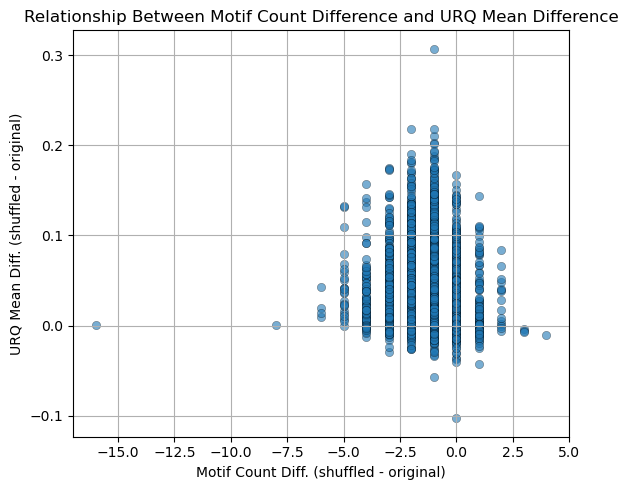

In [35]:
plt.figure(figsize=(6, 5))
plt.scatter(
    merged_df["ctcf_count_diff"],
    merged_df["URQ_mean_diff"],
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3
)
plt.title("Relationship Between Motif Count Difference and URQ Mean Difference")
plt.xlabel("Motif Count Diff. (shuffled - original)")
plt.ylabel("URQ Mean Diff. (shuffled - original)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# Filter the DataFrame for the desired RUQ_mean range
filtered_df = grouped_df[(grouped_df['URQ_mean_og'] >= -0.25) & (grouped_df['URQ_mean_og'] <= -0.15)]

# Calculate the average motif_count in this range
average_motif_count = filtered_df['motif_count'].mean()

print(f"Average motif_count for URQ_mean_og between -0.25 and -0.15: {average_motif_count}")

Average motif_count for URQ_mean_og between -0.25 and -0.15: 1.432296047098402


In [37]:
# Filter the DataFrame for the desired URQ_mean_og range
filtered_df = grouped_df[(grouped_df['URQ_mean_og'] >= -0.35) & (grouped_df['URQ_mean_og'] <= -0.25)]

# Calculate the average motif_count in this range
average_motif_count = filtered_df['motif_count'].mean()

print(f"Average motif_count for URQ_mean_og between -0.35 and -0.25: {average_motif_count}")

Average motif_count for URQ_mean_og between -0.35 and -0.25: 1.5717415115005477


In [38]:
# Filter the DataFrame for the desired URQ_mean_og range
filtered_df = grouped_df[(grouped_df['URQ_mean_og'] >= -0.45) & (grouped_df['URQ_mean_og'] <= -0.35)]

# Calculate the average motif_count in this range
average_motif_count = filtered_df['motif_count'].mean()

print(f"Average motif_count for URQ_mean_og between -0.45 and -0.35: {average_motif_count}")

Average motif_count for URQ_mean_og between -0.45 and -0.35: 1.553191489361702


In [39]:
# Filter the DataFrame for the desired URQ_mean_og range
filtered_df = grouped_df[(grouped_df['URQ_mean_og'] >= -0.55) & (grouped_df['URQ_mean_og'] <= -0.45)]

# Calculate the average motif_count in this range
average_motif_count = filtered_df['motif_count'].mean()

print(f"Average motif_count for URQ_mean_og between -0.55 and -0.45: {average_motif_count}")

Average motif_count for URQ_mean_og between -0.55 and -0.45: 1.5271565495207668


In [40]:
def strand_bias(s):
    strands = list(s)
    if not strands:
        return 0.5
    return strands.count("+") / len(strands)

grouped_df["strand_bias"] = grouped_df["strand_concat"].apply(strand_bias)

In [41]:
grouped_df = grouped_df[grouped_df["motif_count"] < 8]

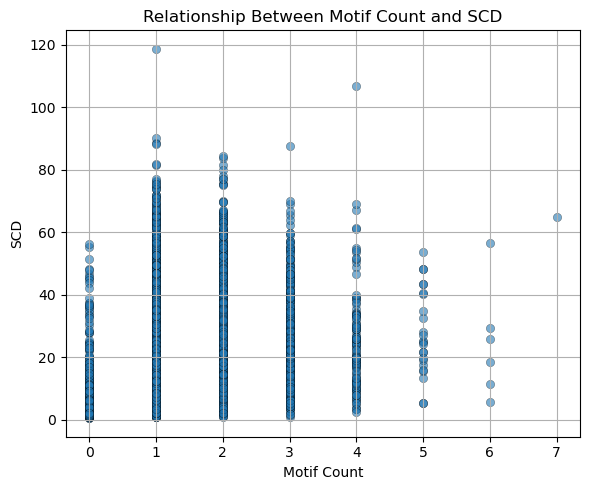

In [42]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["scd"],
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3
)
plt.title("Relationship Between Motif Count and SCD")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

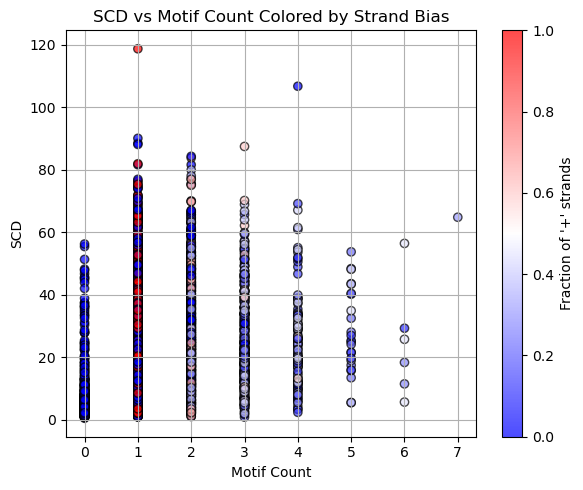

In [43]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("SCD vs Motif Count Colored by Strand Bias")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

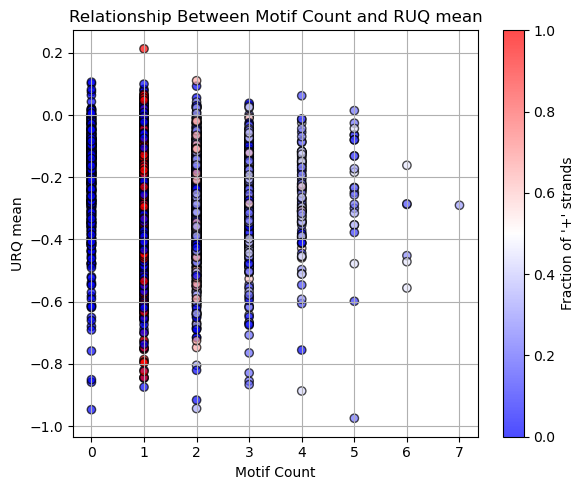

In [44]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["URQ_mean_og"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("Relationship Between Motif Count and RUQ mean")
plt.xlabel("Motif Count")
plt.ylabel("URQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()

### SCD vs. FIMO score (sum and max)

In [45]:
from scipy.stats import pearsonr

# Compute Pearson correlation
r, p = pearsonr(grouped_df["score_max"], grouped_df["scd"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [ ]:
corr_text

In [47]:
x = grouped_df["score_max"]
y = grouped_df["scd"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

: 

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_max"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.title("Relationship Between FIMO Score Max and SCD")
plt.xlabel("FIMO Score Max")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Compute Pearson correlation
r, p = pearsonr(grouped_df["score_sum"], grouped_df["scd"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [ ]:
x = grouped_df["score_sum"]
y = grouped_df["scd"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["score_sum"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.title("Relationship Between FIMO Score Sum and SCD")
plt.xlabel("FIMO Score Sum")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

### URQ mean vs. FIMO score (mean and max)

In [ ]:
x = grouped_df["score_max"]
y = grouped_df["URQ_mean_og"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

In [ ]:
r, p = pearsonr(grouped_df["score_max"], grouped_df["URQ_mean_og"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_max"],
    grouped_df["URQ_mean_og"],
    # c=grouped_df["strand_bias"],
    # cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
# plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.05, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom')

plt.title("Relationship Between FIMO Score Max and Right Upper Quarter mean")
plt.xlabel("FIMO Score Max")
plt.ylabel("URQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
grouped_df.columns

In [ ]:
import seaborn as sns

In [ ]:
# Step 1: Define the bins and labels
bins = [-0.55, -0.45, -0.35, -0.25, -0.15]
labels = ['-0.5', '-0.4', '-0.3', '-0.2']

# Step 2: Create the category column
grouped_df['URQ_category'] = pd.cut(grouped_df['URQ_mean_og'], bins=bins, labels=labels, include_lowest=True)

# Step 3: Drop NaNs if any values fall outside the bin range
filtered_df = grouped_df.dropna(subset=['URQ_category'])

# Step 4: Plot the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='URQ_category', y='score_max', data=filtered_df)
plt.xlabel('URQ_mean_og Category')
plt.ylabel('score_max')
plt.title('score_max by URQ_mean_og Category')
plt.tight_layout()
plt.show()

In [ ]:
# Step 4: Plot the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='URQ_category', y='score_sum', data=filtered_df)
plt.xlabel('URQ_mean_og Category')
plt.ylabel('score_sum')
plt.title('score_sum by URQ_mean_og Category')
plt.tight_layout()
plt.show()

In [ ]:
x = grouped_df["score_sum"]
y = grouped_df["URQ_mean_og"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

In [ ]:
r, p = pearsonr(grouped_df["score_sum"], grouped_df["URQ_mean_og"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_sum"],
    grouped_df["URQ_mean_og"],
    # c=grouped_df["strand_bias"],
    # cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
# plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.05, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom')

plt.title("Relationship Between FIMO Score Sum and Right Upper Quarter mean")
plt.xlabel("FIMO Score Sum")
plt.ylabel("URQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()